In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier # 导入随机森林分类器
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline

In [2]:
# --- 配置参数 ---
DATA_FILE_PATH = r'D:\GitHubRepos\is6400-business-data-analytics\data\loan_data.csv' # Windows路径建议使用原始字符串
TARGET_COLUMN = 'loan_status' # 目标变量列名
TEST_SIZE = 0.2 # 测试集比例
RANDOM_STATE = 42 # 随机种子，确保结果可复现
# 随机森林参数 (可以调整)
N_ESTIMATORS = 200 # 森林中树的数量，是随机森林的一个关键参数
# RF_MAX_DEPTH = None # 可以设置每棵树的最大深度
# RF_MIN_SAMPLES_LEAF = 1 # 可以设置叶节点的最小样本数

In [3]:
# --- 1. 加载数据 ---
print("开始加载数据...")
df = pd.read_csv(DATA_FILE_PATH)
print("数据加载完成。")

开始加载数据...
数据加载完成。


In [4]:
# --- 2. 初始数据清洗和准备 ---
print("进行初步的数据清洗...")
# 处理 describe() 中看到的潜在异常值/错误 - 替换不切实际的值
# 限制年龄和工龄的最大值
df['person_age'] = df['person_age'].apply(lambda x: min(x, 100)) # 年龄上限设为100
df['person_emp_exp'] = df['person_emp_exp'].apply(lambda x: min(x, 60)) # 工龄上限设为60

# 显式转换二元分类特征
df['previous_loan_defaults_on_file'] = df['previous_loan_defaults_on_file'].map({'Yes': 1, 'No': 0}).astype(np.int8)

# 分离特征 (X) 和目标变量 (y)
X = df.drop(TARGET_COLUMN, axis=1)
y = df[TARGET_COLUMN] # 目标变量

# 识别用于预处理的列类型
categorical_features = X.select_dtypes(include='object').columns.tolist()
numerical_features = X.select_dtypes(include=np.number).columns.tolist()

# 确保手动转换的二元特征被视为数值型
if 'previous_loan_defaults_on_file' in numerical_features:
    pass # 已经是数值型
elif 'previous_loan_defaults_on_file' in categorical_features:
    categorical_features.remove('previous_loan_defaults_on_file') # 如果误包含在分类特征中则移除

print(f"分类特征: {categorical_features}")
print(f"数值特征: {numerical_features}")

进行初步的数据清洗...
分类特征: ['person_gender', 'person_education', 'person_home_ownership', 'loan_intent']
数值特征: ['person_age', 'person_income', 'person_emp_exp', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score', 'previous_loan_defaults_on_file']


In [5]:
# --- 3. 定义预处理流程 ---
# 使用 Scikit-learn 组件
print("定义预处理步骤...")
preprocessor = make_column_transformer(
    (OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features), # 对分类特征进行独热编码
    (StandardScaler(), numerical_features), # 对数值特征进行标准化
    remainder='passthrough' # 保留未指定的列
)

定义预处理步骤...


In [6]:
# --- 4. 划分数据 ---
print("将数据划分为训练集和测试集...")
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y # 对分类问题建议进行分层抽样
)

将数据划分为训练集和测试集...


In [7]:
# --- 5. 应用预处理 ---
# 仅在训练数据上拟合 preprocessor，然后转换训练集和测试集
print("应用预处理...")
# 在训练数据上拟合
preprocessor.fit(X_train)

# 转换训练和测试数据
X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# 获取转换后的特征名称（可选，为了方便理解）
try:
    feature_names_out = preprocessor.get_feature_names_out()
    print(f"预处理后的特征数量: {len(feature_names_out)}")
    # 可以选择将处理后的 NumPy 数组转回带有列名的 DataFrame (可选)
    X_train_processed = pd.DataFrame(X_train_processed, columns=feature_names_out, index=X_train.index)
    X_test_processed = pd.DataFrame(X_test_processed, columns=feature_names_out, index=X_test.index)
except AttributeError:
    print("无法自动获取特征名称 (需要 scikit-learn >= 1.0)。处理后的数据是 NumPy 数组。")
    # 如果 get_feature_names_out 失败或未使用，transform 的输出将是 NumPy 数组

应用预处理...
预处理后的特征数量: 26


In [8]:
# --- 6. 训练随机森林模型 (CPU) ---
print(f"在 CPU 上训练随机森林模型 (使用 {N_ESTIMATORS} 棵树)...")
# 创建随机森林分类器实例
rf_cpu = RandomForestClassifier(n_estimators=N_ESTIMATORS,
                                random_state=RANDOM_STATE,
                                n_jobs=-1) # 使用所有可用的CPU核心并行训练
# 你可以调整其他参数, 例如:
# rf_cpu = RandomForestClassifier(n_estimators=N_ESTIMATORS, max_depth=RF_MAX_DEPTH,
#                                 min_samples_leaf=RF_MIN_SAMPLES_LEAF, random_state=RANDOM_STATE, n_jobs=-1)

# 使用处理后的训练数据进行训练
rf_cpu.fit(X_train_processed, y_train)
print("随机森林模型训练完成。")

在 CPU 上训练随机森林模型 (使用 200 棵树)...
随机森林模型训练完成。


In [9]:
# --- 7. 进行预测 (CPU) ---
print("在测试集上进行预测 (CPU)...")
y_pred = rf_cpu.predict(X_test_processed)
print("预测完成。")

在测试集上进行预测 (CPU)...
预测完成。


In [10]:
# --- 8. 评估模型 ---
print("\n--- 模型评估指标 ---")

# 分类报告
print("\n分类报告:")
print(classification_report(y_test, y_pred))

# 混淆矩阵
print("\n混淆矩阵:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

# 更好地可视化混淆矩阵:
print("\n混淆矩阵 (带标签):")
print("          预测为0   预测为1") # 注意空格用于对齐
print(f"实际为0:    {cm[0, 0]:<10} {cm[0, 1]:<10}")
print(f"实际为1:    {cm[1, 0]:<10} {cm[1, 1]:<10}")

print("\n--- 脚本执行完毕 ---")


--- 模型评估指标 ---

分类报告:
              precision    recall  f1-score   support

           0       0.93      0.98      0.96      7000
           1       0.90      0.76      0.83      2000

    accuracy                           0.93      9000
   macro avg       0.92      0.87      0.89      9000
weighted avg       0.93      0.93      0.93      9000


混淆矩阵:
[[6836  164]
 [ 477 1523]]

混淆矩阵 (带标签):
          预测为0   预测为1
实际为0:    6836       164       
实际为1:    477        1523      

--- 脚本执行完毕 ---


              precision    recall  f1-score   support

      Normal       0.93      0.98      0.96      7000
  Defaulting       0.90      0.76      0.83      2000

    accuracy                           0.93      9000
   macro avg       0.92      0.87      0.89      9000
weighted avg       0.93      0.93      0.93      9000

[[6836  164]
 [ 477 1523]]


<Figure size 1000x800 with 0 Axes>

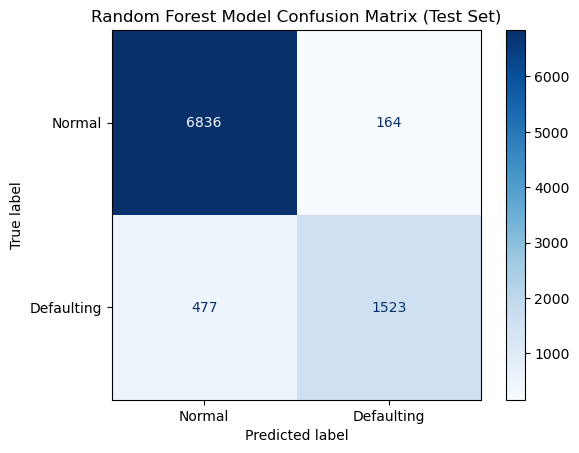


--- 脚本执行完毕 ---


In [ ]:
from matplotlib import pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

report = classification_report(y_test, y_pred, target_names=['Normal', 'Defaulting'])
print(report)

cm = confusion_matrix(y_test, y_pred)
print(cm)

# 可视化混淆矩阵
try:
    # 设置图像尺寸和分辨率
    plt.figure(figsize=(10, 8), dpi=100)
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Defaulting'])
    disp.plot(cmap=plt.cm.Blues)
    
    # 设置标题
    plt.title('Random Forest Model Confusion Matrix (Test Set)')
    
    # 保存高清图片
    plt.savefig(r'D:\GitHubRepos\is6400-business-data-analytics\loan_data_analytics\image\result_figs\rf_confusion_matrix.png', dpi=600, bbox_inches='tight')
    
    # 显示图像
    plt.show()
except Exception as e:
    print(f"\n无法显示混淆矩阵图: {e}")

print("\n--- 脚本执行完毕 ---")